# Modelado Yelp: regresión y clasificación

Esta notebook reúne de forma ordenada el trabajo de modelado realizado sobre el dataset de Yelp, separando por modelo y dejando claro qué objetivo, qué métricas se usan y cómo interpretar los resultados.

Se estructura en dos grandes bloques:
- Regresión: predicción del volumen de check-ins (`n_checkins`)
- Clasificación: predicción de usuario elite vs no elite (`elite_encoded`)

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from scipy.stats import pointbiserialr

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)


def find_datasets_dir(folder_name: str = 'datasets') -> Path:
    start = Path.cwd()
    candidates = []

    # Búsqueda directa desde la ubicación actual y sus padres
    for d in (start, *start.parents):
        candidates.append(d / folder_name)
        candidates.append(d / 'yelp_dataset' / folder_name)

    # Búsqueda adicional por el árbol de trabajo del proyecto
    candidates.extend([
        start / 'yelp_dataset' / folder_name,
        start.parent / 'yelp_dataset' / folder_name,
    ])

    for candidate in candidates:
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError(
        f"No se encontró la carpeta '{folder_name}' desde {start}. "
        "Se esperaba en 'yelp_dataset/datasets'."
    )


def read_json_sample(path, nrows=100_000):
    return pd.read_json(path, lines=True, nrows=nrows)


def drop_if_exists(df, columns):
    existing = [col for col in columns if col in df.columns]
    return df.drop(columns=existing)


BASE_PATH = find_datasets_dir()
SAMPLE_ROWS = 100_000
print(f'Datasets encontrados en: {BASE_PATH}')
print(f'Versión resumida trabajando con una muestra de hasta {SAMPLE_ROWS:,} filas por archivo grande.')

Datasets encontrados en: c:\Users\usuario\Documents\Especialización IA\yelp_dataset\datasets
Versión resumida trabajando con una muestra de hasta 100,000 filas por archivo grande.


In [28]:
print('Cargando datasets (muestra resumida)...')

df_user = read_json_sample(BASE_PATH / 'yelp_academic_dataset_user.json', nrows=SAMPLE_ROWS)
df_review = read_json_sample(BASE_PATH / 'yelp_academic_dataset_review.json', nrows=SAMPLE_ROWS)
df_tip = read_json_sample(BASE_PATH / 'yelp_academic_dataset_tip.json', nrows=SAMPLE_ROWS)
df_business = read_json_sample(BASE_PATH / 'yelp_academic_dataset_business.json', nrows=SAMPLE_ROWS)
df_checkin = read_json_sample(BASE_PATH / 'yelp_academic_dataset_checkin.json', nrows=SAMPLE_ROWS)
df_checkin['n_checkins'] = df_checkin['date'].fillna('').apply(lambda x: 0 if not str(x).strip() else str(x).count(',') + 1)

print('Carga finalizada.')

# Resumen rápido de los datasets
summary_datasets = pd.DataFrame({
    'Dataset': ['Users', 'Reviews', 'Tips', 'Check-ins', 'Business'],
    'Filas': [len(df_user), len(df_review), len(df_tip), len(df_checkin), len(df_business)],
    'Columnas': [df_user.shape[1], df_review.shape[1], df_tip.shape[1], df_checkin.shape[1], df_business.shape[1]],
    'NaN totales': [int(df_user.isna().sum().sum()), int(df_review.isna().sum().sum()), int(df_tip.isna().sum().sum()), int(df_checkin.isna().sum().sum()), int(df_business.isna().sum().sum())],
})

display(summary_datasets)

Cargando datasets (muestra resumida)...
Carga finalizada.


,Dataset,Filas,Columnas,NaN totales
0,Users,100000,22,0
1,Reviews,100000,9,0
2,Tips,100000,5,0
3,Check-ins,100000,3,0
4,Business,100000,14,24590


## 1) Regresión: predicción de `n_checkins`

El objetivo es predecir la cantidad de visitas de un negocio. Para reducir la asimetría de la distribución se trabaja con la transformación `log1p`, y luego se vuelve a la escala original con `expm1` para calcular métricas interpretables.

In [29]:
# Preparación del dataset de regresión

# Se agregan variables útiles para modelado
biz = df_business[['business_id', 'stars', 'review_count', 'state', 'city', 'is_open', 'attributes', 'hours']].copy()
biz = biz.set_index('business_id').join(df_checkin.set_index('business_id')['date'].fillna('').apply(lambda x: 0 if not str(x).strip() else str(x).count(',') + 1).rename('n_checkins'), how='inner')


def n_attributes(attr):
    if isinstance(attr, dict):
        return len(attr)
    return 0


def n_days_open(hours):
    if isinstance(hours, dict):
        return sum(1 for v in hours.values() if v and str(v).strip() != '0:0-0:0')
    return 0


biz['n_attributes'] = biz['attributes'].apply(n_attributes)
biz['n_days_open'] = biz['hours'].apply(n_days_open)

le_state = LabelEncoder()
biz['state_enc'] = le_state.fit_transform(biz['state'].fillna('Unknown'))
city_freq = biz['city'].value_counts()
biz['city_freq'] = biz['city'].map(city_freq).fillna(1)

feature_cols = ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
X = biz[feature_cols].fillna(0).astype(float)
y_log = np.log1p(biz['n_checkins'])
y_raw = biz['n_checkins']

print(f'Features: {feature_cols}')
print(f'Target n_checkins: media={y_raw.mean():.1f} | mediana={y_raw.median():.1f} | max={y_raw.max():,}')
print(f'log1p(n_checkins): media={y_log.mean():.3f} | std={y_log.std():.3f} | skew={y_log.skew():.3f}')

Features: ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
Target n_checkins: media=104.8 | mediana=20.0 | max=52,144
log1p(n_checkins): media=3.182 | std=1.625 | skew=0.446


### Modelo 1: regresión lineal

La regresión lineal sirve como baseline interpretativo. Es el punto de comparación más sencillo y permite entender la relación lineal entre las variables predictoras y la cantidad esperada de check-ins.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_raw = np.expm1(y_test)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_log = lr.predict(X_test)
pred_raw = np.expm1(pred_log)

lr_metrics = {
    'MAE (log)': mean_absolute_error(y_test, pred_log),
    'RMSE (log)': np.sqrt(mean_squared_error(y_test, pred_log)),
    'R² (log)': r2_score(y_test, pred_log),
    'MAE (orig)': mean_absolute_error(y_test_raw, pred_raw),
    'RMSE (orig)': np.sqrt(mean_squared_error(y_test_raw, pred_raw)),
}

print('Métricas de regresión lineal:')
for k, v in lr_metrics.items():
    print(f'{k}: {v:.4f}')

Métricas de regresión lineal:
MAE (log): 0.9747
RMSE (log): 1.2360
R² (log): 0.4180
MAE (orig): 12739369.8736
RMSE (orig): 1207100916.8341


#### Métricas características de la regresión lineal

- MAE (log): error medio absoluto en la escala transformada
- RMSE (log): penaliza más los errores grandes
- R² (log): proporción de varianza explicada
- MAE (orig): error absoluto sobre escala original
- RMSE (orig): error cuadrático medio sobre escala original

La regresión lineal es útil como baseline, pero no captura relaciones no lineales que podrían existir entre la popularidad del negocio y sus atributos.

### Modelo 2: random forest regressor

El random forest es un modelo no lineal que suele tener mejor capacidad de capturar interacciones complejas entre variables y suele mejorar el baseline lineal.

Métricas de Random Forest regressor:
MAE (log): 0.7697
RMSE (log): 0.9831
R² (log): 0.6318
MAE (orig): 58.4685
RMSE (orig): 394.6972


,Importancia
review_count,0.7864
n_attributes,0.0788
city_freq,0.0393
stars,0.0379
n_days_open,0.0272
state_enc,0.0251
is_open,0.0053


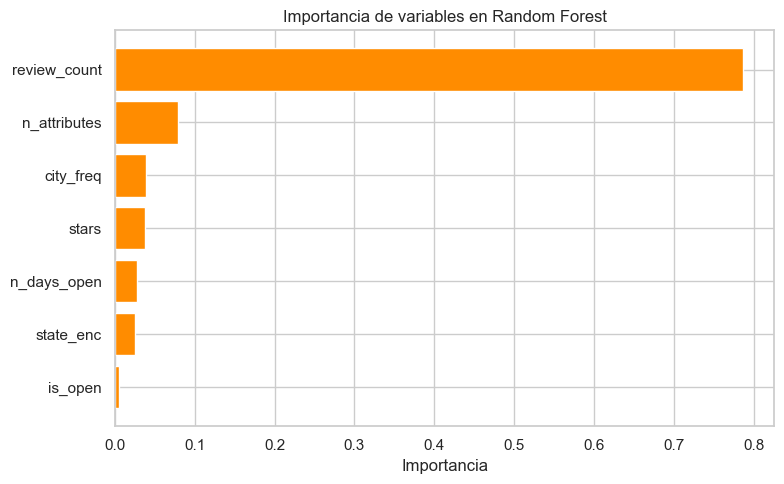

In [31]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_log = rf.predict(X_test)
rf_pred_raw = np.expm1(rf_pred_log)

rf_metrics = {
    'MAE (log)': mean_absolute_error(y_test, rf_pred_log),
    'RMSE (log)': np.sqrt(mean_squared_error(y_test, rf_pred_log)),
    'R² (log)': r2_score(y_test, rf_pred_log),
    'MAE (orig)': mean_absolute_error(y_test_raw, rf_pred_raw),
    'RMSE (orig)': np.sqrt(mean_squared_error(y_test_raw, rf_pred_raw)),
}

print('Métricas de Random Forest regressor:')
for k, v in rf_metrics.items():
    print(f'{k}: {v:.4f}')

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances.to_frame('Importancia'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color='darkorange')
ax.set_title('Importancia de variables en Random Forest')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

#### Métricas características de Random Forest

- R² (log): indica qué tan bien explica la varianza el modelo en la escala transformada
- MAE y RMSE: reflejan la magnitud del error de predicción
- Importancia de variables: muestra qué features tienen más peso en la decisión del bosque

En general, este modelo suele superar al baseline lineal cuando existen interacciones no lineales o efectos no proporcionales entre las variables.

## 2) Clasificación: usuario elite vs no elite

En esta parte del análisis se construye una variable binaria: `elite_encoded = 1` si el usuario es elite y `0` en caso contrario. Luego se comparan varios modelos para ver qué tan bien separan el caso positivo.

In [32]:
# Preparación del dataset de clasificación

def classify_elite(value):
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        cleaned = value.strip()
        return 1 if cleaned not in ['', 'None', 'none', '[]'] else 0
    if isinstance(value, (list, tuple, set)):
        return 1 if len(value) > 0 else 0
    return 1 if bool(value) else 0


df_binclass = df_user.copy()
df_binclass["elite_encoded"] = df_binclass["elite"].apply(classify_elite)
df_binclass = drop_if_exists(df_binclass, ['elite', 'name', 'friends', 'elite_years', 'yelping_since', 'user_id'])
print(df_binclass['elite_encoded'].value_counts())
print(df_binclass.head())

elite_encoded
0    80138
1    19862
Name: count, dtype: int64
   review_count  useful  funny   cool  fans  average_stars  compliment_hot  \
0           585    7217   1259   5994   267         3.9100             250   
1          4333   43091  13066  27281  3138         3.7400            1145   
2           665    2086   1010   1003    52         3.3200              89   
3           224     512    330    299    28         4.2700              24   
4            79      29     15      7     1         3.5400               1   

   compliment_more  compliment_profile  compliment_cute  compliment_list  \
0               65                  55               56               18   
1              264                 184              157              251   
2               13                  10               17                3   
3                4                   1                6                2   
4                1                   0                0                0   

   complimen

In [33]:
def chequear_correl(df):
    matriz_correl = df.corr(method='pearson')

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        matriz_correl,
        cmap='coolwarm',
        annot=True,
        fmt='.2f',
        center=0
    )
    plt.title('Correlación entre atributos')
    plt.show()

    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    high_corr = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.8
    ]

    for c1, c2, corr_val in sorted(high_corr, key=lambda x: -x[2]):
        print(f'{c1} - {c2}: {corr_val:.3f}')


def rank_correlacionadas(df, target='elite_encoded', threshold=0.8):
    corr_features = df.drop(columns=[target]).corr().abs()
    target_corr = df.drop(columns=[target]).corrwith(df[target]).abs()
    upper = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))

    resultados = []
    for col in upper.columns:
        for row in upper.index:
            corr_value = upper.loc[row, col]
            if pd.notna(corr_value) and corr_value > threshold:
                resultados.append({
                    'feature_1': row,
                    'feature_2': col,
                    'feature_corr': corr_value,
                    'target_corr_1': target_corr[row],
                    'target_corr_2': target_corr[col],
                    'conservar': row if target_corr[row] > target_corr[col] else col,
                })

    return pd.DataFrame(resultados).sort_values('feature_corr', ascending=False)


def point_biserial_ranking(df, target='elite_encoded'):
    resultados = []
    for col in df.select_dtypes(include='number').columns:
        if col == target:
            continue
        corr, pvalue = pointbiserialr(df[target], df[col])
        resultados.append({
            'atributo': col,
            'correlación': corr,
            'pvalor': pvalue,
        })

    resultados = pd.DataFrame(resultados)
    return resultados.sort_values('correlación', key=abs, ascending=False)

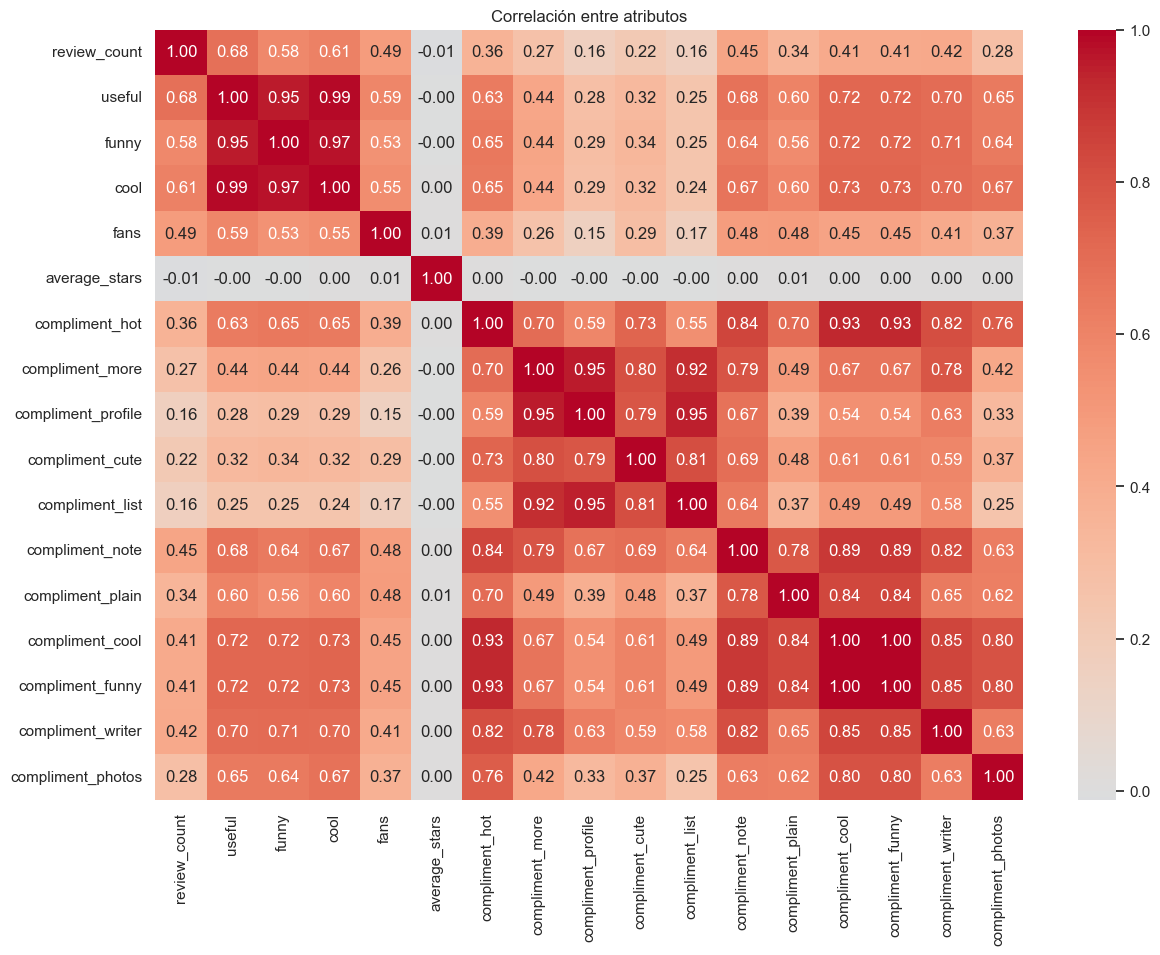

compliment_funny - compliment_cool: 1.000
cool - useful: 0.991
cool - funny: 0.970
funny - useful: 0.955
compliment_profile - compliment_more: 0.954
compliment_list - compliment_profile: 0.948
compliment_cool - compliment_hot: 0.932
compliment_funny - compliment_hot: 0.932
compliment_list - compliment_more: 0.917
compliment_cool - compliment_note: 0.889
compliment_funny - compliment_note: 0.889
compliment_writer - compliment_cool: 0.845
compliment_writer - compliment_funny: 0.845
compliment_note - compliment_hot: 0.844
compliment_cool - compliment_plain: 0.837
compliment_funny - compliment_plain: 0.837
compliment_writer - compliment_hot: 0.817
compliment_writer - compliment_note: 0.816
compliment_list - compliment_cute: 0.814
compliment_cute - compliment_more: 0.803


In [34]:
df_dummy = df_binclass.drop(columns=['elite_encoded'])
chequear_correl(df_dummy)

In [35]:
rank_correlacionadas(df_binclass)

,feature_1,feature_2,feature_corr,target_corr_1,target_corr_2,conservar
15,compliment_cool,compliment_funny,1.0000,0.1541,0.1541,compliment_funny
1,useful,cool,0.9912,0.2112,0.1652,useful
2,funny,cool,0.9700,0.1464,0.1652,cool
0,useful,funny,0.9548,0.2112,0.1464,useful
3,compliment_more,compliment_profile,0.9537,0.1080,0.0501,compliment_more
6,compliment_profile,compliment_list,0.9480,0.0501,0.0546,compliment_list
12,compliment_hot,compliment_funny,0.9319,0.1360,0.1541,compliment_funny
9,compliment_hot,compliment_cool,0.9319,0.1360,0.1541,compliment_cool
5,compliment_more,compliment_list,0.9174,0.1080,0.0546,compliment_more
13,compliment_note,compliment_funny,0.8890,0.1767,0.1541,compliment_note


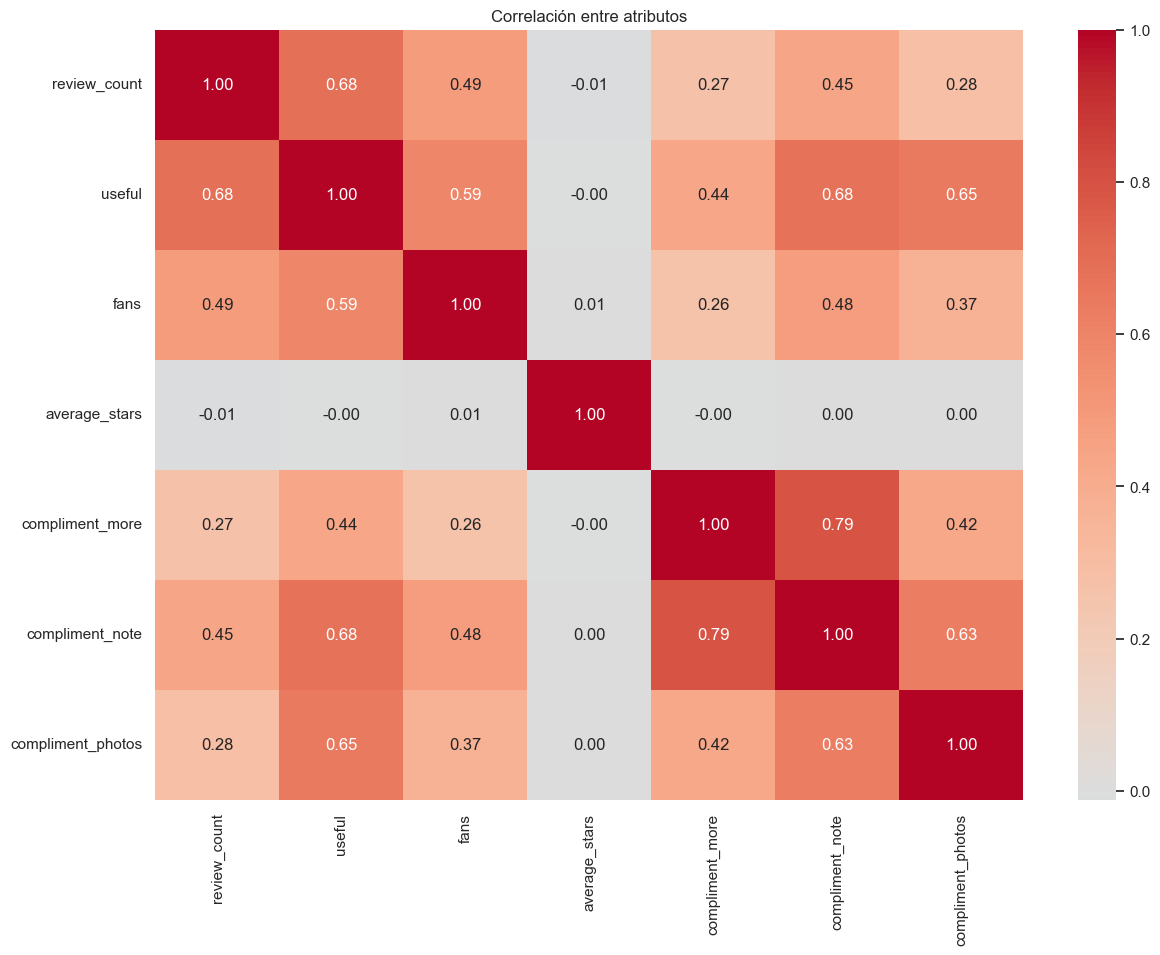

In [36]:
df_binclass = drop_if_exists(df_binclass, ['compliment_cool', 'cool', 'total_compliments', 'funny', 'compliment_profile', 'compliment_hot', 'compliment_list', 'compliment_funny', 'compliment_plain', 'compliment_writer', 'compliment_cute'])
df_dummy = df_binclass.drop(columns=['elite_encoded'])
chequear_correl(df_dummy)

In [37]:
point_biserial_ranking(df_binclass)

,atributo,correlación,pvalor
0,review_count,0.4678,0.0000
1,useful,0.2112,0.0000
2,fans,0.2091,0.0000
5,compliment_note,0.1767,0.0000
4,compliment_more,0.1080,0.0000
6,compliment_photos,0.0898,0.0000
3,average_stars,0.0404,0.0000


### Baseline heurístico

Antes de entrenar modelos más complejos, se define una heurística que combina tres indicadores de actividad y reputación del usuario.

Regla:
- más de 100 reviews
- más de 5 fans
- más de 200 votos useful

Si al menos 2 de 3 condiciones se cumplen, se clasifica como elite.

In [38]:
class HeuristicaElite:
    def predict_score(self, X):
        return (
            (X["review_count"] > 100).astype(int) +
            (X["fans"] > 5).astype(int) +
            (X["useful"] > 200).astype(int)
        )

    def predict(self, X):
        return (self.predict_score(X) >= 2).astype(int)


X_binclass = df_binclass.drop(columns=['elite_encoded'])
y_binclass = df_binclass['elite_encoded']
X_binclass_train, X_binclass_test, y_binclass_train, y_binclass_test = train_test_split(
    X_binclass,
    y_binclass,
    test_size=0.2,
    random_state=42,
    stratify=y_binclass,
)

heuristica = HeuristicaElite()
y_binclass_pred_heur = heuristica.predict(X_binclass_test)
y_binclass_score_heur = heuristica.predict_score(X_binclass_test)

print(f"Exactitud =, {accuracy_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"F1 =, {f1_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"Precisión =, {precision_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"Recall =, {recall_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"ROC-AUC =, {roc_auc_score(y_binclass_test, y_binclass_score_heur):.4f}")

Exactitud =, 0.9124
F1 =, 0.7647
Precisión =, 0.8201
Recall =, 0.7163
ROC-AUC =, 0.9038


#### Métricas características de la heurística

- Exactitud: proporción de predicciones correctas
- F1: equilibrio entre precision y recall
- Precisión: proporción de positivos predichos correctamente
- Recall: capacidad de detectar verdaderos positivos
- ROC-AUC: capacidad global de ordenamiento del modelo

La heurística funciona bien como baseline ligero y computacionalmente barato. Es útil para comparar modelos más complejos.

### Modelo 3: regresión logística

La regresión logística es un modelo lineal clásico para clasificación binaria. Como muchas variables tienen escalas distintas, se aplica `StandardScaler` antes de entrenar.

In [39]:
scaler = StandardScaler()
X_binclass_train_scaled = scaler.fit_transform(X_binclass_train)
X_binclass_test_scaled = scaler.transform(X_binclass_test)

logistica = LogisticRegression(max_iter=1000)
logistica.fit(X_binclass_train_scaled, y_binclass_train)
y_pred_logistica = logistica.predict(X_binclass_test_scaled)
y_score_logistica = logistica.predict_proba(X_binclass_test_scaled)[:, 1]

logistica_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_logistica),
    'F1': f1_score(y_binclass_test, y_pred_logistica),
    'Precisión': precision_score(y_binclass_test, y_pred_logistica),
    'Recall': recall_score(y_binclass_test, y_pred_logistica),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_logistica),
}

print('Métricas de Regresión Logística:')
for k, v in logistica_metrics.items():
    print(f'{k}: {v:.4f}')

Métricas de Regresión Logística:
Exactitud: 0.8994
F1: 0.6980
Precisión: 0.8643
Recall: 0.5853
ROC-AUC: 0.9588


#### Métricas características de la regresión logística

- Exactitud: porcentaje de aciertos globales
- F1: útil si hay desbalance de clases
- Precisión: mide cuántos de los clasificados como elite realmente lo son
- Recall: mide cuántos elite reales fueron detectados
- ROC-AUC: capacidad discriminativa del modelo

Este modelo es interpretable y sirve como comparación directa con modelos más complejos.

### Modelo 4: SVM

Support Vector Machine es un modelo potente para separación de clases. En este caso, se usa una versión lineal y se escala el conjunto antes del entrenamiento.

In [40]:
svm = LinearSVC(random_state=42, max_iter=5000)
svm.fit(X_binclass_train_scaled, y_binclass_train)
y_pred_svm = svm.predict(X_binclass_test_scaled)
y_score_svm = svm.decision_function(X_binclass_test_scaled)

svm_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_svm),
    'F1': f1_score(y_binclass_test, y_pred_svm),
    'Precisión': precision_score(y_binclass_test, y_pred_svm),
    'Recall': recall_score(y_binclass_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_svm),
}

print('Métricas de SVM:')
for k, v in svm_metrics.items():
    print(f'{k}: {v:.4f}')

Métricas de SVM:
Exactitud: 0.8871
F1: 0.6358
Precisión: 0.8846
Recall: 0.4962
ROC-AUC: 0.9593


#### Métricas características del SVM

- Exactitud: proporción de predicciones correctas
- F1: balance entre precisión y recall
- ROC-AUC: capacidad de separar ambas clases en la frontera aprendida
- Precisión y recall: útiles para detectar si el modelo prioriza evitar falsos positivos o falsos negativos

El SVM suele rendir bien cuando la separación entre clases es clara, pero la escala de las variables es clave para su desempeño.

### Modelo 5: decision tree classifier

El árbol de decisión es interpretable y aprende reglas simples a partir de los atributos. Es útil como modelo de referencia de estructura no lineal.

In [41]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_binclass_train, y_binclass_train)
y_pred_dt = dt.predict(X_binclass_test)
y_score_dt = dt.predict_proba(X_binclass_test)[:, 1]

dt_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_dt),
    'F1': f1_score(y_binclass_test, y_pred_dt),
    'Precisión': precision_score(y_binclass_test, y_pred_dt),
    'Recall': recall_score(y_binclass_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_dt),
}

print('Métricas de Decision Tree:')
for k, v in dt_metrics.items():
    print(f'{k}: {v:.4f}')

Métricas de Decision Tree:
Exactitud: 0.8954
F1: 0.7363
Precisión: 0.7373
Recall: 0.7354
ROC-AUC: 0.8352


#### Métricas características del Decision Tree

- Exactitud y F1: muestran cómo de bien generaliza el árbol
- Precisión/Recall: indican la sensibilidad del árbol a errores de clasificación
- ROC-AUC: mide la separabilidad de clases bajo el árbol

Es muy interpretable, pero debe controlarse el overfitting porque el árbol puede memorizar patrones del conjunto de entrenamiento.

### Modelo 6: random forest classifier

El random forest classifier combina varios árboles para reducir la varianza del modelo individual y ofrecer un clasificador más robusto.

In [42]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_binclass_train, y_binclass_train)
y_pred_rf = rf_clf.predict(X_binclass_test)
y_score_rf = rf_clf.predict_proba(X_binclass_test)[:, 1]

rf_clf_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_rf),
    'F1': f1_score(y_binclass_test, y_pred_rf),
    'Precisión': precision_score(y_binclass_test, y_pred_rf),
    'Recall': recall_score(y_binclass_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_rf),
}

print('Métricas de Random Forest Classifier:')
for k, v in rf_clf_metrics.items():
    print(f'{k}: {v:.4f}')

Métricas de Random Forest Classifier:
Exactitud: 0.9236
F1: 0.8028
Precisión: 0.8236
Recall: 0.7830
ROC-AUC: 0.9695


#### Métricas características del Random Forest Classifier

- Exactitud: representa la capacidad global del modelo
- F1: una métrica muy útil cuando la clase positiva es minoritaria
- Precisión y recall: ayudan a entender si el modelo prioriza evitar falsos positivos o detectar más casos reales
- ROC-AUC: refleja la capacidad del modelo para distinguir entre clases

Este modelo suele ofrecer un equilibrio sólido entre rendimiento, estabilidad y capacidad de modelado no lineal.

In [43]:
# Resumen comparativo final
results = {
    'Heurística': {
        'Exactitud': accuracy_score(y_binclass_test, y_binclass_pred_heur),
        'F1': f1_score(y_binclass_test, y_binclass_pred_heur),
        'Precisión': precision_score(y_binclass_test, y_binclass_pred_heur),
        'Recall': recall_score(y_binclass_test, y_binclass_pred_heur),
        'ROC-AUC': roc_auc_score(y_binclass_test, y_binclass_score_heur),
    },
    'Regresión Logística': logistica_metrics,
    'SVM': svm_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_clf_metrics,
}

metrics_df = pd.DataFrame(results).T
print('\nComparación final de modelos de clasificación:')
display(metrics_df.round(4))


Comparación final de modelos de clasificación:


,Exactitud,F1,Precisión,Recall,ROC-AUC
Heurística,0.9124,0.7647,0.8201,0.7163,0.9038
Regresión Logística,0.8994,0.6980,0.8643,0.5853,0.9588
SVM,0.8871,0.6358,0.8846,0.4962,0.9593
Decision Tree,0.8954,0.7363,0.7373,0.7354,0.8352
Random Forest,0.9236,0.8028,0.8236,0.7830,0.9695


## Conclusión general

El trabajo de modelado quedó organizado en dos frentes:

1. Regresión
   - Regresión lineal como baseline
   - Random Forest como modelo no lineal más completo

2. Clasificación
   - Heurística como referencia básica
   - Regresión logística, SVM, árboles de decisión y random forest para comparar rendimiento

La comparación final se debe interpretar con cuidado según el objetivo:
- si se busca interpretabilidad, la regresión lineal y los árboles son muy útiles
- si se prioriza rendimiento, el random forest suele ofrecer mejores resultados
- si se busca equilibrio entre simplicidad y capacidad predictiva, la regresión logística y la heurística son opciones muy razonables

Este esquema permite mantener todo el análisis ordenado por modelo, con sus métricas y su interpretación en un único lugar.